In [ ]:
! pip install pdfplumber

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/6.6 MB ? eta -:--:--
   --- ------------------------------------ 0.5/6.6 MB 8.2 MB/s eta 0:00:01
   --------- ------------------------------ 1.6/6.6 MB 4.4 MB/s eta 0:00:02
   --------------- ------------------------ 2.6/6.6 MB 4.6 MB/s eta 0:00:01
   ----------------------- ---------------- 3.9/6.6 MB 5.1 MB/s eta 0:00:01
   ------------------------------- -------- 5.2/6.6 MB 5.5 MB/s eta 0:00:01
   ---------------------------------------  6.6/6.6 MB 5.5 MB/s eta 0:00:01
   ---------------------------------------- 6.6/6.6 MB 5.4 MB/s  0:00:01
   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--
   --------------- ------------------------ 1.3/3.5 MB 6.1 MB/s eta 0:00:01
   ------------------------------ --------- 2.6/3.5 MB 6.6 MB/s eta 0:00:01
   ---------------------------------------- 3.5/3.5 MB 6.9 MB/s  0:00:00
   ---------------------------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
! pip install gensim

Defaulting to user installation because normal site-packages is not writeable


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
    --------------------------------------- 0.5/24.4 MB 2.8 MB/s eta 0:00:09
   --- ------------------------------------ 1.8/24.4 MB 5.0 MB/s eta 0:00:05
   ---- ----------------------------------- 2.6/24.4 MB 4.6 MB/s eta 0:00:05
   ------ --------------------------------- 3.9/24.4 MB 5.1 MB/s eta 0:00:05
   -------- ------------------------------- 5.2/24.4 MB 5.3 MB/s eta 0:00:04
   ---------- ----------------------------- 6.6/24.4 MB 5.6 MB/s eta 0:00:04
   ------------ --------------------------- 7.6/24.4 MB 5.4 MB/s eta 0:00:04
   -------------- ------------------------- 8.9/24.4 MB 5.5 MB/s eta 0:00:03
   ---------------- ----------------------- 10.2/24.4 MB 5.6 MB/s eta 0:00:03
   ------------------ --------------------- 11.5/24.4 MB 5.7 MB/s eta 0:00:03
   ------------------- -------------------- 12.1/24.4 MB 5.7 MB/s eta 0:00:03
   --------------------- ------------------ 13.4/24.4 MB 5.4 MB/s eta 0:00:03
 

###Importing modules

In [1]:
import requests
import pdfplumber
from bs4 import BeautifulSoup
import re
import nltk
from nltk.tokenize import word_tokenize
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import random

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
import os
from nltk.corpus import stopwords

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Shruti\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Shruti\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Shruti\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


###Data Collection

In [2]:
documents = []

#Scrape content from the website
def scrape_site1():
    url = "https://anandmishra22.github.io/"
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    paras = soup.find_all("p", align="justify")

    text = []
    for p in paras:
        for a in p.find_all("a"):
            a.unwrap()
        text.append(p.get_text(" ", strip=True))

    return " ".join(text)

def scrape_iitj_pg():
    url = "https://iitj.ac.in/computer-science-engineering/en/Postgraduate-Programs"
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    content = soup.select("h6, p")

    text = []
    for tag in content:
        t = tag.get_text(" ", strip=True)
        if len(t.split()) > 4:
            text.append(t)

    return " ".join(text)


# add website text to documents
documents.append(scrape_site1())
documents.append(scrape_iitj_pg())

In [3]:
#Extracting text from the pdf
def extract_text_from_pdf(file_path):
    text = ""
    
    with pdfplumber.open(file_path) as pdf:
        for page in pdf.pages:
            page_text = page.extract_text()
            if page_text:
                text += page_text + " "
    
    return text

In [4]:
pdf_folder = "pdfs"
for file in os.listdir(pdf_folder):
    if file.endswith(".pdf"):
        path = os.path.join(pdf_folder, file)
        text = extract_text_from_pdf(path)
        # print(text)
        documents.append(text)

print("Total documents:", len(documents))

Total documents: 4


In [5]:
print(documents)

["Currently, I serve as an Assistant Professor at the Department of Computer Science and Engineering at the Indian Institute of Technology Jodhpur . Prior to this role, I had the opportunity to work as a Postdoctoral Researcher under the mentorship \n          of Dr. Partha Pratim Talukdar at the Indian Institute of Science , focusing on Knowledge-aware Computer Vision for nearly two years. \n          For my doctoral studies, I conducted research on the interpretation of text within scene images at IIIT Hyderabad , \n          where I had the privilege of being supervised by Prof. C. V. Jawahar and Dr. Karteek Alahari . My current research interest lies in the intersection of vision and language. \n       Specifically, I am deeply engaged in exploring the field of developing AI Agents \n       that can understand human language and perceive and comprehend the visual world.\n       The overarching goal of my research group at IIT Jodhpur, known as Vision, Language, and Learning Group o

###Data Preprocessing

In [6]:
stop_words = set(stopwords.words('english')) #For removing english stopwords

clean_docs = []  
for doc in documents:
    
    doc = doc.lower()   # lowercase
    
    #Substituting B.Tech -> btech, M.Tech. -> mtech 
    doc = re.sub(r'\bb\.?\s*tech\.?\b', 'btech', doc)
    doc = re.sub(r'\bm\.?\s*tech\.?\b', 'mtech', doc)
    doc = re.sub(r'\bm\.?\s*sc\.?\b', 'msc', doc)
    doc = re.sub(r'\bph\.?\s*d\.?\b', 'phd', doc)
    doc = re.sub(r'\bb\.?\s*sc\.?\b', 'bsc', doc)
    doc = re.sub(r'\bb\.?\s*e\.?\b', 'be', doc)
    
    # remove URLs
    doc = re.sub(r'http\S+', '', doc)
    
    # remove numbers
    doc = re.sub(r'\d+', ' ', doc)
    
    # remove punctuation
    doc = re.sub(r'[^\w\s]', ' ', doc)
    
    # remove extra spaces
    doc = re.sub(r'\s+', ' ', doc)
    
    # tokenize
    tokens = word_tokenize(doc)
    
    # keep only valid words
    tokens = [w for w in tokens if w.isalpha()]
    
    # remove short words and very long words
    tokens = [w for w in tokens if 3 <= len(w) < 15]
    
    # remove stopwords
    tokens = [w for w in tokens if w not in stop_words]
    
    clean_docs.append(tokens)

In [7]:
print(clean_docs)

[['currently', 'serve', 'assistant', 'professor', 'department', 'computer', 'science', 'engineering', 'indian', 'institute', 'technology', 'jodhpur', 'prior', 'role', 'opportunity', 'work', 'postdoctoral', 'researcher', 'mentorship', 'partha', 'pratim', 'talukdar', 'indian', 'institute', 'science', 'focusing', 'knowledge', 'aware', 'computer', 'vision', 'nearly', 'two', 'years', 'doctoral', 'studies', 'conducted', 'research', 'interpretation', 'text', 'within', 'scene', 'images', 'iiit', 'hyderabad', 'privilege', 'supervised', 'prof', 'jawahar', 'karteek', 'alahari', 'current', 'research', 'interest', 'lies', 'intersection', 'vision', 'language', 'specifically', 'deeply', 'engaged', 'exploring', 'field', 'developing', 'agents', 'understand', 'human', 'language', 'perceive', 'comprehend', 'visual', 'world', 'overarching', 'goal', 'research', 'group', 'iit', 'jodhpur', 'known', 'vision', 'language', 'learning', 'group', 'short', 'advance', 'development', 'intelligent', 'agents', 'towards

In [8]:
with open("corpus.txt", "w", encoding="utf-8") as f:
    for doc in clean_docs:
        f.write(" ".join(doc) + "\n")

print("Corpus file saved")

Corpus file saved


In [9]:
#Corpus
corpus=[]
for doc in clean_docs:
    corpus.extend(doc)
    
print(corpus)

['currently', 'serve', 'assistant', 'professor', 'department', 'computer', 'science', 'engineering', 'indian', 'institute', 'technology', 'jodhpur', 'prior', 'role', 'opportunity', 'work', 'postdoctoral', 'researcher', 'mentorship', 'partha', 'pratim', 'talukdar', 'indian', 'institute', 'science', 'focusing', 'knowledge', 'aware', 'computer', 'vision', 'nearly', 'two', 'years', 'doctoral', 'studies', 'conducted', 'research', 'interpretation', 'text', 'within', 'scene', 'images', 'iiit', 'hyderabad', 'privilege', 'supervised', 'prof', 'jawahar', 'karteek', 'alahari', 'current', 'research', 'interest', 'lies', 'intersection', 'vision', 'language', 'specifically', 'deeply', 'engaged', 'exploring', 'field', 'developing', 'agents', 'understand', 'human', 'language', 'perceive', 'comprehend', 'visual', 'world', 'overarching', 'goal', 'research', 'group', 'iit', 'jodhpur', 'known', 'vision', 'language', 'learning', 'group', 'short', 'advance', 'development', 'intelligent', 'agents', 'towards'

###Dataset Statistics

In [10]:
num_documents = len(clean_docs)
total_tokens = len(corpus)
vocab_size = len(set(corpus))

print("\nDataset Statistics")
print("-------------------")
print("Documents:", num_documents)
print("Tokens:", total_tokens)
print("Vocabulary Size:", vocab_size)


Dataset Statistics
-------------------
Documents: 4
Tokens: 15077
Vocabulary Size: 1736


###Top 10 most frequent words

In [157]:
word_freq = Counter(corpus)

print("\nTop 10 Frequent Words:")
print(word_freq.most_common(10))


Top 10 Frequent Words:
[('student', 358), ('course', 258), ('mtech', 252), ('phd', 234), ('degree', 208), ('semester', 186), ('students', 180), ('academic', 174), ('program', 166), ('requirements', 143)]


###Word Cloud

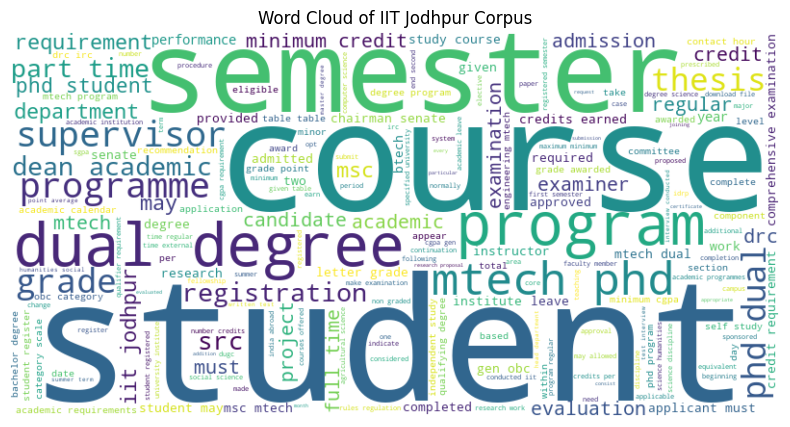

In [12]:
text_for_cloud = " ".join(corpus)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_for_cloud)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of IIT Jodhpur Corpus")
plt.show()

###Task 2: Model Training

In [13]:
tokens=[]
# load corpus
with open("corpus.txt", "r", encoding="utf-8") as f:
    tokens = f.read().split()

# build vocabulary
word_counts = Counter(tokens)
# print(word_counts)
vocab = list(word_counts.keys())

word_to_idx = {w:i for i,w in enumerate(vocab)}
idx_to_word = {i:w for w,i in word_to_idx.items()}
print(word_to_idx)
print(idx_to_word)
vocab_size = len(vocab)

corpus_indices = [word_to_idx[w] for w in tokens]

{'currently': 0, 'serve': 1, 'assistant': 2, 'professor': 3, 'department': 4, 'computer': 5, 'science': 6, 'engineering': 7, 'indian': 8, 'institute': 9, 'technology': 10, 'jodhpur': 11, 'prior': 12, 'role': 13, 'opportunity': 14, 'work': 15, 'postdoctoral': 16, 'researcher': 17, 'mentorship': 18, 'partha': 19, 'pratim': 20, 'talukdar': 21, 'focusing': 22, 'knowledge': 23, 'aware': 24, 'vision': 25, 'nearly': 26, 'two': 27, 'years': 28, 'doctoral': 29, 'studies': 30, 'conducted': 31, 'research': 32, 'interpretation': 33, 'text': 34, 'within': 35, 'scene': 36, 'images': 37, 'iiit': 38, 'hyderabad': 39, 'privilege': 40, 'supervised': 41, 'prof': 42, 'jawahar': 43, 'karteek': 44, 'alahari': 45, 'current': 46, 'interest': 47, 'lies': 48, 'intersection': 49, 'language': 50, 'specifically': 51, 'deeply': 52, 'engaged': 53, 'exploring': 54, 'field': 55, 'developing': 56, 'agents': 57, 'understand': 58, 'human': 59, 'perceive': 60, 'comprehend': 61, 'visual': 62, 'world': 63, 'overarching': 64

In [14]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

###Continuous Bag of Word

In [15]:
def gen_cbow_data(corpus, window_size):

    data = []  #Stores (context, target) pairs
    for i in range(window_size, len(corpus)-window_size):

        context = [] 
        # iterate over window positions around the target word
        for j in range(-window_size, window_size+1):
            if j != 0: #skip the target word
                context.append(corpus[i+j])  #append surrounding word index to context

        target = corpus[i]

        data.append((context, target))

    return data

In [16]:
def train_cbow(data, vocab_size, embed_dim, lr=0.01, epochs=50):
 # W1: input embedding matrix (each row = word vector) | shape= vocab_size x embed_dim
    W1 = np.random.randn(vocab_size, embed_dim)
    W2 = np.random.randn(embed_dim, vocab_size) # W2: output weight matrix | shape = embed_dim x vocab_size
    
    epoch_loss=[]
    for epoch in range(epochs):

        total_loss = 0

        for context, target in data: # iterate over each training samples

            context_vec = np.mean(W1[context], axis=0)  # get embeddings of context words and average them
            
            # compute scores for all words in vocabulary
            scores = np.dot(context_vec, W2)

            probs = np.exp(scores) / np.sum(np.exp(scores)) # convert scores to probabilities

            loss = -np.log(probs[target])
            total_loss += loss

            grad_out = probs
            grad_out[target] -= 1

            grad_W2 = np.outer(context_vec, grad_out) #gradient wrt W2
            grad_context = np.dot(W2, grad_out) #gradient wrt context vector
             
             # gradient of softmax + cross entropy
            for word in context:
                W1[word] -= lr * grad_context

            W2 -= lr * grad_W2  #update output weights
        epoch_loss.append(total_loss)
        print(f"Epoch {epoch+1}, Loss: {total_loss}")


    return W1, epoch_loss

In [17]:
window_size = 2
cbow_data = gen_cbow_data(corpus_indices, window_size)
print(cbow_data)

[([0, 1, 3, 4], 2), ([1, 2, 4, 5], 3), ([2, 3, 5, 6], 4), ([3, 4, 6, 7], 5), ([4, 5, 7, 8], 6), ([5, 6, 8, 9], 7), ([6, 7, 9, 10], 8), ([7, 8, 10, 11], 9), ([8, 9, 11, 12], 10), ([9, 10, 12, 13], 11), ([10, 11, 13, 14], 12), ([11, 12, 14, 15], 13), ([12, 13, 15, 16], 14), ([13, 14, 16, 17], 15), ([14, 15, 17, 18], 16), ([15, 16, 18, 19], 17), ([16, 17, 19, 20], 18), ([17, 18, 20, 21], 19), ([18, 19, 21, 8], 20), ([19, 20, 8, 9], 21), ([20, 21, 9, 6], 8), ([21, 8, 6, 22], 9), ([8, 9, 22, 23], 6), ([9, 6, 23, 24], 22), ([6, 22, 24, 5], 23), ([22, 23, 5, 25], 24), ([23, 24, 25, 26], 5), ([24, 5, 26, 27], 25), ([5, 25, 27, 28], 26), ([25, 26, 28, 29], 27), ([26, 27, 29, 30], 28), ([27, 28, 30, 31], 29), ([28, 29, 31, 32], 30), ([29, 30, 32, 33], 31), ([30, 31, 33, 34], 32), ([31, 32, 34, 35], 33), ([32, 33, 35, 36], 34), ([33, 34, 36, 37], 35), ([34, 35, 37, 38], 36), ([35, 36, 38, 39], 37), ([36, 37, 39, 40], 38), ([37, 38, 40, 41], 39), ([38, 39, 41, 42], 40), ([39, 40, 42, 43], 41), ([4

In [21]:
embedding_dim = 100
cbow_embeddings, losses = train_cbow(cbow_data, vocab_size, embedding_dim,epochs=15)

Epoch 1, Loss: 202378.59339069924
Epoch 2, Loss: 133540.1442402825
Epoch 3, Loss: 102310.41335474109
Epoch 4, Loss: 82668.28583762208
Epoch 5, Loss: 68822.52342195068
Epoch 6, Loss: 58396.255994478925
Epoch 7, Loss: 50265.87051235176
Epoch 8, Loss: 43784.4936896221
Epoch 9, Loss: 38514.269665384476
Epoch 10, Loss: 34160.797868425165
Epoch 11, Loss: 30524.745968197174
Epoch 12, Loss: 27460.81767457525
Epoch 13, Loss: 24855.085534596557
Epoch 14, Loss: 22617.260061690486
Epoch 15, Loss: 20679.648244726563


###Nearest neighbours (CBOW)

In [22]:
def nearest_neighbors(word, embeddings, word_to_idx, idx_to_word, top_k=5):

    if word not in word_to_idx:
        print(f"{word} not in vocabulary")
        return []

    word_idx = word_to_idx[word]

    word_vec = embeddings[word_idx].reshape(1, -1)

    similarities = cosine_similarity(word_vec, embeddings)[0]
    #print(similarities)
    sorted_indices = np.argsort(-similarities)

    neighbors = []

    for idx in sorted_indices:
        if idx != word_idx:
            neighbors.append((idx_to_word[idx], similarities[idx]))
        if len(neighbors) == top_k:
            break

    return neighbors

In [24]:
query_words = ["research", "student", "phd", "exam"]
print("Using CBOW embeddings")
for word in query_words:

    results = nearest_neighbors(word, cbow_embeddings, word_to_idx, idx_to_word)

    print(f"\nTop 5 nearest neighbors of the word: {word}")

    for w, score in results:
        print(f"{w}  ({score:.4f})")

Using CBOW embeddings

Top 5 nearest neighbors of the word: research
stay  (0.3527)
monitor  (0.3218)
changes  (0.3180)
held  (0.3123)
branch  (0.3096)

Top 5 nearest neighbors of the word: student
world  (0.3671)
students  (0.3665)
admissions  (0.3407)
approved  (0.3163)
allocated  (0.3094)

Top 5 nearest neighbors of the word: phd
msc  (0.4615)
degree  (0.3777)
earned  (0.3439)
drc  (0.3365)
opt  (0.3324)

Top 5 nearest neighbors of the word: exam
lectures  (0.4291)
deems  (0.2855)
worth  (0.2850)
endorsement  (0.2674)
theendof  (0.2670)


###Analogy Experiment (CBOW)

In [93]:
def analogy(wordA, wordB, wordC, embeddings, word_to_idx, idx_to_word, top_k=5):

    # check vocabulary
    if wordA not in word_to_idx or wordB not in word_to_idx or wordC not in word_to_idx:
        print("One of the words not in vocabulary")
        return []

    # vector arithmetic: B - A + C
    vec = (embeddings[word_to_idx[wordB]] - embeddings[word_to_idx[wordA]] + embeddings[word_to_idx[wordC]])
    # cosine similarity with all embeddings
    similarities = np.dot(embeddings, vec) / (np.linalg.norm(embeddings, axis=1) * np.linalg.norm(vec) + 1e-9)

    # sort descending
    sorted_indices = np.argsort(-similarities)

    results = []
    for idx in sorted_indices:
        word = idx_to_word[idx]

        # exclude input words
        if word not in [wordA, wordB, wordC]:
            results.append((word, similarities[idx]))

        if len(results) == top_k:
            break

    return results

In [90]:
print("student : exam :: professor : ?")

results = analogy("student", "exam", "professor", cbow_embeddings, word_to_idx, idx_to_word)
if results:
    for w, score in results:
        print(w, score)


student : exam :: professor : ?
lectures 0.37101766304003014
deems 0.31904855594023285
national 0.3157336676693165
attends 0.30151540878201416
resubmit 0.2897056815692457


In [92]:
print("course : exam :: research : ?")

results = analogy("course", "exam", "research", cbow_embeddings, word_to_idx, idx_to_word)
if results:
    for w, score in results:
        print(w, score)


course : exam :: research : ?
supplementary 0.31492198344056843
lectures 0.2954801711563506
type 0.283044039699325
absent 0.27038310353558204
worth 0.2679871222564297


In [41]:
print("semester : course :: degree : ?")

results = analogy("semester", "course", "degree", cbow_embeddings, word_to_idx, idx_to_word)
if results:
    for w, score in results:
        print(w, score)


semester : course :: degree : ?
phd 0.43631157869095755
msc 0.3754801635629281
determine 0.3176501728327205
certified 0.30887972902279726
unsatisfactory 0.28889325864818416


In [44]:
selected_words = ["research","phd","student","exam","course","faculty","learning","program","project","university","data","computer","btech","mtech","research","credit"]

In [45]:
selected_words = [w for w in selected_words if w in word_to_idx]

In [46]:
from sklearn.decomposition import PCA

###Visualization (CBOW)

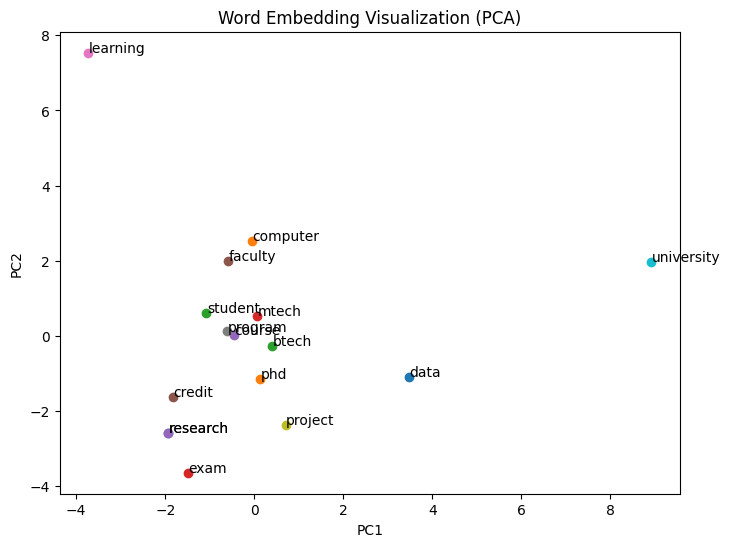

In [47]:
vectors = []
words = []

for word in selected_words:
    vectors.append(cbow_embeddings[word_to_idx[word]])
    words.append(word)

vectors = np.array(vectors)
pca = PCA(n_components=2)

vectors_2d = pca.fit_transform(vectors)
plt.figure(figsize=(8,6))

for i, word in enumerate(words):

    x, y = vectors_2d[i]

    plt.scatter(x, y)

    plt.text(x+0.01, y+0.01, word)

plt.title("Word Embedding Visualization (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [48]:
from numpy.linalg import norm
def cosine_similarity(a, b):
    return np.dot(a, b) / (norm(a) * norm(b) + 1e-9)


def nearest_words(word, embeddings, word_to_idx, idx_to_word, top_k=5):
    idx = word_to_idx[word]
    vec = embeddings[idx]

    sims = []
    for i in range(len(embeddings)):
        if i != idx:
            sim = cosine_similarity(vec, embeddings[i])
            sims.append((idx_to_word[i], sim))

    sims.sort(key=lambda x: x[1], reverse=True)
    return sims[:top_k]

###Effect of embedding dimension on CBOW

In [55]:
embedding_dims = [50, 100, 200]

results_dim = {}
embeddings_dim = {}   

window_size = 2
cbow_data = gen_cbow_data(corpus_indices, window_size)

for dim in embedding_dims:

    print("\nTraining CBOW with embedding dim =", dim)
    embeddings, losses = train_cbow(cbow_data,vocab_size,embed_dim=dim,epochs=15)
    results_dim[dim] = losses
    embeddings_dim[dim] = embeddings   


Training CBOW with embedding dim = 50
Epoch 1, Loss: 159539.74394483597
Epoch 2, Loss: 119132.43673871223
Epoch 3, Loss: 100451.72028841132
Epoch 4, Loss: 88098.06755176494
Epoch 5, Loss: 78978.9982089837
Epoch 6, Loss: 71830.0458724826
Epoch 7, Loss: 65987.80037613037
Epoch 8, Loss: 61075.74752477937
Epoch 9, Loss: 56857.42516855782
Epoch 10, Loss: 53174.538876939245
Epoch 11, Loss: 49917.880423731614
Epoch 12, Loss: 47008.56089659948
Epoch 13, Loss: 44388.54098840945
Epoch 14, Loss: 42013.8442952381
Epoch 15, Loss: 39849.67513392416

Training CBOW with embedding dim = 100
Epoch 1, Loss: 204403.37858025415
Epoch 2, Loss: 134578.8404721237
Epoch 3, Loss: 103102.39732018614
Epoch 4, Loss: 83381.08711164731
Epoch 5, Loss: 69536.65410166158
Epoch 6, Loss: 59145.418613669826
Epoch 7, Loss: 51020.14059938439
Epoch 8, Loss: 44500.26121717675
Epoch 9, Loss: 39174.90712886371
Epoch 10, Loss: 34779.65869605995
Epoch 11, Loss: 31110.33323781037
Epoch 12, Loss: 28008.020856895375
Epoch 13, Loss:

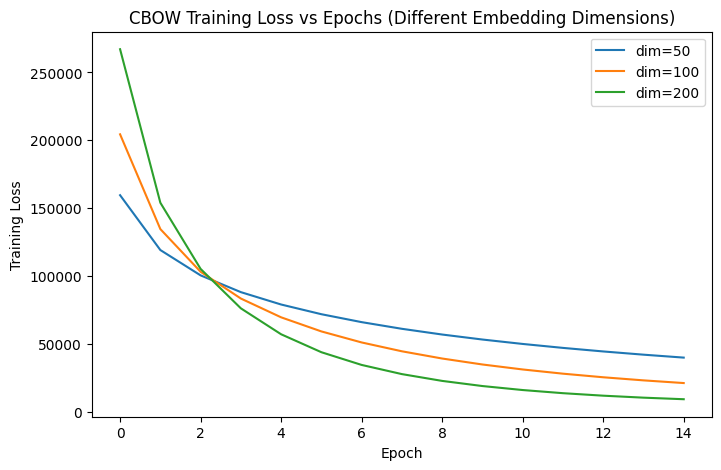

In [56]:
plt.figure(figsize=(8,5))
for dim, losses in results_dim.items():
    plt.plot(losses, label=f"dim={dim}")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("CBOW Training Loss vs Epochs (Different Embedding Dimensions)")
plt.legend()
plt.show()

In [59]:
test_words = ["btech", "professor"]

for dim in embedding_dims:
    print(f"\nEmbedding dim = {dim}")

    for word in test_words:
        if word in word_to_idx:
            print(f"\nNearest to '{word}':")
            print(nearest_words( word, embeddings_dim[dim], word_to_idx,idx_to_word))


Embedding dim = 50

Nearest to 'btech':
[('semesters', 0.442869469859779), ('sanction', 0.4379010739811362), ('engineering', 0.43658690487778795), ('ongoing', 0.4140601033633761), ('dual', 0.4074719347449477)]

Nearest to 'professor':
[('decided', 0.4439103354516803), ('sabbatical', 0.44050977920864504), ('separately', 0.4260228024500059), ('student', 0.3893465058187828), ('dean', 0.3881777316773423)]

Embedding dim = 100

Nearest to 'btech':
[('compulsory', 0.4095030601848361), ('submit', 0.3284356753087475), ('appeal', 0.32267988370619927), ('submission', 0.32143264170482), ('phd', 0.3213245643315113)]

Nearest to 'professor':
[('breaks', 0.28087304947797226), ('head', 0.27685655798926095), ('availability', 0.27521669061169995), ('nbhm', 0.26807495740021964), ('review', 0.2661445839263668)]

Embedding dim = 200

Nearest to 'btech':
[('digital', 0.28018959697647383), ('paced', 0.2715997004266761), ('msc', 0.26776954973309464), ('one', 0.2592821033281881), ('incomplete', 0.25517310177

###Effect of window size on CBOW

In [60]:
window_sizes = [2, 4, 6]

results_window = {}
embeddings_window = {}   # store embeddings

embedding_dim = 100

for w in window_sizes:

    print("\nTraining CBOW with window size =", w)

    cbow_data = gen_cbow_data(corpus_indices, w)

    embeddings, losses = train_cbow(cbow_data,vocab_size,embed_dim=embedding_dim,epochs=15)

    results_window[w] = losses
    embeddings_window[w] = embeddings   # store embeddings


Training CBOW with window size = 2
Epoch 1, Loss: 202371.16277268305
Epoch 2, Loss: 133973.15647988257
Epoch 3, Loss: 102888.56504514386
Epoch 4, Loss: 83148.67762493843
Epoch 5, Loss: 69227.67901017795
Epoch 6, Loss: 58799.791436746185
Epoch 7, Loss: 50679.328507884675
Epoch 8, Loss: 44190.90845105452
Epoch 9, Loss: 38915.62403349766
Epoch 10, Loss: 34564.709052364764
Epoch 11, Loss: 30929.098274976852
Epoch 12, Loss: 27853.147583893257
Epoch 13, Loss: 25223.051101029832
Epoch 14, Loss: 22956.500004423222
Epoch 15, Loss: 20991.211516032505

Training CBOW with window size = 4
Epoch 1, Loss: 152442.76909416507
Epoch 2, Loss: 105127.28708914088
Epoch 3, Loss: 83656.74755100007
Epoch 4, Loss: 69602.87632304826
Epoch 5, Loss: 59348.86044363919
Epoch 6, Loss: 51439.29067992842
Epoch 7, Loss: 45103.29310673868
Epoch 8, Loss: 39893.47800646035
Epoch 9, Loss: 35527.02558575381
Epoch 10, Loss: 31818.604986907274
Epoch 11, Loss: 28638.10454383004
Epoch 12, Loss: 25888.173266225454
Epoch 13, Los

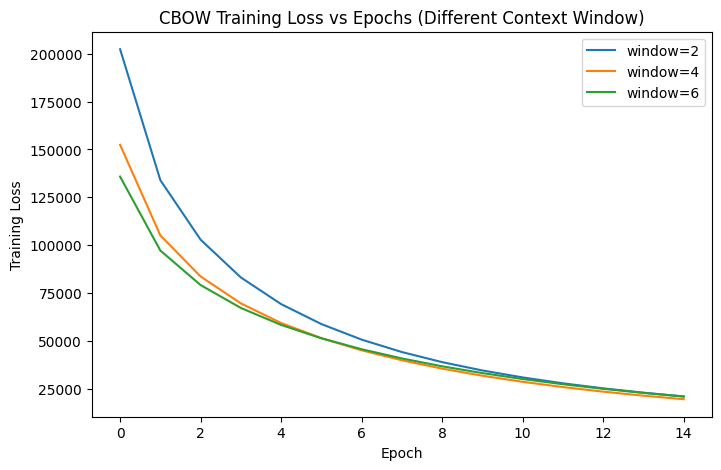

In [61]:
plt.figure(figsize=(8,5))

for w, losses in results_window.items():
    plt.plot(losses, label=f"window={w}")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("CBOW Training Loss vs Epochs (Different Context Window)")
plt.legend()
plt.show()

In [62]:
test_words = ["btech", "professor"]

for w in window_sizes:
    print(f"\nWindow size = {w}")

    for word in test_words:
        if word in word_to_idx:
            print(f"\nNearest to '{word}':")
            print(nearest_words(word,embeddings_window[w],word_to_idx,idx_to_word))


Window size = 2

Nearest to 'btech':
[('discussion', 0.3678954060273714), ('would', 0.33754564767825296), ('duration', 0.328937958462653), ('gap', 0.3181657050223896), ('msc', 0.304731716148626)]

Nearest to 'professor':
[('curricula', 0.3705352921427959), ('pass', 0.30871098272831643), ('registers', 0.29561382918915863), ('evaluated', 0.29049369710902384), ('motion', 0.2876008138329338)]

Window size = 4

Nearest to 'btech':
[('weekends', 0.3831532880712801), ('academic', 0.38161046317045916), ('semesters', 0.35829056843159945), ('endeavors', 0.3538735618638226), ('directives', 0.3305116313694426)]

Nearest to 'professor':
[('requested', 0.349805242384785), ('postdoctoral', 0.3327456076552966), ('use', 0.32159899626828126), ('curricula', 0.28079234058662855), ('sme', 0.2799159650880679)]

Window size = 6

Nearest to 'btech':
[('commencement', 0.38986773785573203), ('lecture', 0.3235708099250884), ('conditions', 0.31591631133914605), ('financial', 0.3153382091627096), ('full', 0.30243

###SkipGram

In [104]:
def gen_skipgram_data(corpus, window_size):

    data = [] #stores training data (target, context) pairs
    for i in range(window_size, len(corpus)-window_size):

        target = corpus[i] #center word

        for j in range(-window_size, window_size+1): #iterate over surrounding words
            if j != 0:
                context = corpus[i+j]
                data.append((target, context))

    return data

In [105]:
def negative_sampling(vocab_size, positive_idx, k): 
    #k -> number of neg samples
    #positive_idx-> actual context word index
    
    negatives = [] #stores randomly sampled neg word indices
    while len(negatives) < k:
        neg = random.randint(0, vocab_size-1) #randomly pick a word from vocab

        if neg != positive_idx: #to ensure neg sample is not the positive idx
            negatives.append(neg)

    return negatives

In [106]:
def train_skipgram_neg(data, vocab_size, embed_dim, neg_samples=5, lr=0.01, epochs=30):

    # W_in : input embedding matrix (target word embeddings)
    # shape = vocab_size x embed_dim
    W_in = np.random.randn(vocab_size, embed_dim)

    # W_out : output embedding matrix (context word embeddings)
    # shape = vocab_size x embed_dim
    W_out = np.random.randn(vocab_size, embed_dim)
    ep=1e-9
    epoch_loss = []  

    for epoch in range(epochs):

        total_loss = 0 

        # iterate over each (target, context) pair
        for target, context in data:

            # embedding of target word
            v_c = W_in[target]

            # embedding of positive context word
            u_o = W_out[context]

            # computation for the Positive pairs

            score_pos = sigmoid(np.dot(v_c, u_o))

            # positive loss: maximize similarity
            loss = -np.log(score_pos+ep)

            # gradient for positive pair
            grad_pos = score_pos - 1

            # update context embedding
            W_out[context] -= lr * grad_pos * v_c

            # update target embedding
            W_in[target] -= lr * grad_pos * u_o
            # For negative samples

            # sample k negative words
            negatives = negative_sampling(vocab_size, context, neg_samples)

            for neg in negatives:

                # embedding of negative word
                u_k = W_out[neg]

                # compute similarity 
                score_neg = sigmoid(np.dot(v_c, u_k))

                # negative loss: minimize similarity
                loss += -np.log(1 - score_neg+ep)

                # gradient for negative sample
                grad_neg = score_neg

                # update negative context embedding
                W_out[neg] -= lr * grad_neg * v_c

                # update target embedding
                W_in[target] -= lr * grad_neg * u_k

            total_loss += loss

 
        epoch_loss.append(total_loss)

        print(f"Epoch {epoch+1}, Loss: {total_loss}")

    return W_in, epoch_loss

In [136]:
window_size = 2
skipgram_data = gen_skipgram_data(corpus_indices, window_size)
print(skipgram_data)

[(2, 0), (2, 1), (2, 3), (2, 4), (3, 1), (3, 2), (3, 4), (3, 5), (4, 2), (4, 3), (4, 5), (4, 6), (5, 3), (5, 4), (5, 6), (5, 7), (6, 4), (6, 5), (6, 7), (6, 8), (7, 5), (7, 6), (7, 8), (7, 9), (8, 6), (8, 7), (8, 9), (8, 10), (9, 7), (9, 8), (9, 10), (9, 11), (10, 8), (10, 9), (10, 11), (10, 12), (11, 9), (11, 10), (11, 12), (11, 13), (12, 10), (12, 11), (12, 13), (12, 14), (13, 11), (13, 12), (13, 14), (13, 15), (14, 12), (14, 13), (14, 15), (14, 16), (15, 13), (15, 14), (15, 16), (15, 17), (16, 14), (16, 15), (16, 17), (16, 18), (17, 15), (17, 16), (17, 18), (17, 19), (18, 16), (18, 17), (18, 19), (18, 20), (19, 17), (19, 18), (19, 20), (19, 21), (20, 18), (20, 19), (20, 21), (20, 8), (21, 19), (21, 20), (21, 8), (21, 9), (8, 20), (8, 21), (8, 9), (8, 6), (9, 21), (9, 8), (9, 6), (9, 22), (6, 8), (6, 9), (6, 22), (6, 23), (22, 9), (22, 6), (22, 23), (22, 24), (23, 6), (23, 22), (23, 24), (23, 5), (24, 22), (24, 23), (24, 5), (24, 25), (5, 23), (5, 24), (5, 25), (5, 26), (25, 24), (25

In [137]:
embedding_dim = 100
neg_samples = 5
sg_embeddings, loss = train_skipgram_neg(skipgram_data, vocab_size, embedding_dim, neg_samples)

Epoch 1, Loss: 1060595.23164437
Epoch 2, Loss: 635756.3770221655
Epoch 3, Loss: 420509.7493819811
Epoch 4, Loss: 312353.8656818556
Epoch 5, Loss: 246004.89654105186
Epoch 6, Loss: 202746.84743799362
Epoch 7, Loss: 172392.84693465114
Epoch 8, Loss: 148291.7023484685
Epoch 9, Loss: 129737.77340357754
Epoch 10, Loss: 116344.47115912379
Epoch 11, Loss: 105118.55594454042
Epoch 12, Loss: 94998.76976439392
Epoch 13, Loss: 88064.86190333571
Epoch 14, Loss: 81515.21142744551
Epoch 15, Loss: 76879.63454879358
Epoch 16, Loss: 72332.27857158956
Epoch 17, Loss: 68470.81223396034
Epoch 18, Loss: 64174.883279602655
Epoch 19, Loss: 61510.95089417543
Epoch 20, Loss: 59455.01783079974
Epoch 21, Loss: 56972.148574549734
Epoch 22, Loss: 54107.58546371234
Epoch 23, Loss: 53084.20875035271
Epoch 24, Loss: 51172.81838492951
Epoch 25, Loss: 50416.61352920193
Epoch 26, Loss: 48800.75115738354
Epoch 27, Loss: 47083.68060936232
Epoch 28, Loss: 45833.710512084544
Epoch 29, Loss: 45205.55013774597
Epoch 30, Loss:

###Nearest Neigbors (SkipGram)

In [138]:
from numpy.linalg import norm

def nearest_neighbors_sg(word, embeddings, word_to_idx, idx_to_word, top_k=5):

    if word not in word_to_idx:
        return []

    word_idx = word_to_idx[word]

    # target word vector
    word_vec = embeddings[word_idx]

    # compute cosine similarity with all words
    similarities = np.dot(embeddings, word_vec) / (
        norm(embeddings, axis=1) * norm(word_vec) + 1e-9
    )

    # sort by similarity
    sorted_indices = np.argsort(-similarities)

    results = []
    for idx in sorted_indices[1:top_k+1]:
        results.append((idx_to_word[idx], similarities[idx]))

    return results

In [139]:
query_words = ["research", "student", "phd", "exam"]
print("Using skip gram embeddings")
for word in query_words:

    results = nearest_neighbors_sg(word, sg_embeddings, word_to_idx, idx_to_word)
    print(f"\nTop 5 nearest neighbors of the word: {word}")
    for similar_word, score in results:
        print(f"{similar_word}: {score:.4f}")

Using skip gram embeddings

Top 5 nearest neighbors of the word: research
work: 0.4328
presentation: 0.4305
structures: 0.4263
sum: 0.4152
cleared: 0.4086

Top 5 nearest neighbors of the word: student
may: 0.5068
alone: 0.4769
admitted: 0.4438
required: 0.4415
allowed: 0.4279

Top 5 nearest neighbors of the word: phd
mtech: 0.6040
degree: 0.5810
semesters: 0.4777
points: 0.4752
dual: 0.4317

Top 5 nearest neighbors of the word: exam
absence: 0.4409
agricultural: 0.4227
intersection: 0.4124
suggested: 0.4117
computer: 0.3870


###Analogy Experiment (Skipgram)

In [140]:
print("student : exam :: professor : ?")

results = analogy("student", "exam", "professor", sg_embeddings, word_to_idx, idx_to_word)

for w, score in results:
    print(w, score)

student : exam :: professor : ?
absence 0.48430192960377977
agricultural 0.4802883031810802
chosen 0.44325047936430456
functioning 0.4365416069995168
act 0.4363934729881929


In [141]:
print("course : exam :: research : ?")

results = analogy("course", "exam", "research", sg_embeddings, word_to_idx, idx_to_word)

for w, score in results:
    print(w, score)

course : exam :: research : ?
areas 0.4128270770062106
intersection 0.38869208435280866
going 0.38770244951527155
absence 0.3798913682951913
appointment 0.37580773907002146


In [142]:
print("semester : course :: degree : ?")

results = analogy("semester", "course", "degree", sg_embeddings, word_to_idx, idx_to_word)

for w, score in results:
    print(w, score)

semester : course :: degree : ?
dual 0.5207601519228204
mtech 0.45368351881289354
engineering 0.45299530578361413
governors 0.4295526990701692
automatic 0.4107977980067838


###Visualization (Skipgram)

In [143]:
selected_words = ["research","phd","student","exam","course","faculty","learning","program","project","university","data","computer","btech","mtech","research","credit"]

In [144]:
selected_words = [w for w in selected_words if w in word_to_idx]

In [145]:
vectors = []
words = []

for word in selected_words:
    vectors.append(sg_embeddings[word_to_idx[word]])
    words.append(word)

vectors = np.array(vectors)

In [146]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

vectors_2d = pca.fit_transform(vectors)

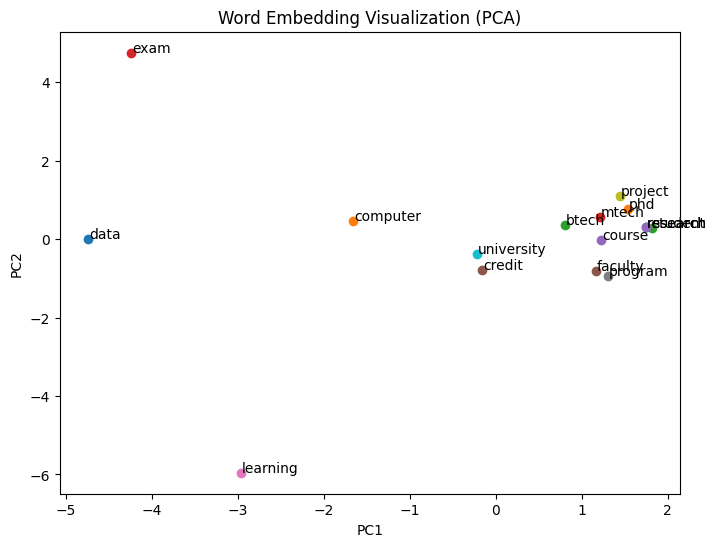

In [147]:
plt.figure(figsize=(8,6))
for i, word in enumerate(words):

    x, y = vectors_2d[i]

    plt.scatter(x, y)

    plt.text(x+0.01, y+0.01, word)

plt.title("Word Embedding Visualization (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

###Effect of window size on Skipgram 

In [148]:
window_sizes = [2, 4, 6]

results_window_sg = {}
embeddings_window_sg = {}

embedding_dim = 100

for w in window_sizes:

    print("\nTraining Skipgram with window size =", w)

    skip_data = gen_skipgram_data(corpus_indices, w)

    embeddings, losses = train_skipgram_neg(skip_data,vocab_size,embed_dim=embedding_dim,epochs=15)
    results_window_sg[w] = losses
    embeddings_window_sg[w] = embeddings


Training Skipgram with window size = 2
Epoch 1, Loss: 1061581.7634950131
Epoch 2, Loss: 636811.2117357388
Epoch 3, Loss: 424725.9508972962
Epoch 4, Loss: 313133.7983846568
Epoch 5, Loss: 247203.20456222983
Epoch 6, Loss: 202475.25069281922
Epoch 7, Loss: 171300.76652366284
Epoch 8, Loss: 147800.26415339622
Epoch 9, Loss: 129195.64384580238
Epoch 10, Loss: 115753.17047697671
Epoch 11, Loss: 104368.25319090259
Epoch 12, Loss: 96191.53992633834
Epoch 13, Loss: 87501.79505793235
Epoch 14, Loss: 81622.08587630888
Epoch 15, Loss: 76426.50654696715

Training Skipgram with window size = 4
Epoch 1, Loss: 1714689.0103141307
Epoch 2, Loss: 778818.5338876687
Epoch 3, Loss: 513998.9377637644
Epoch 4, Loss: 385549.4802096401
Epoch 5, Loss: 311900.55571535754
Epoch 6, Loss: 264192.0265150712
Epoch 7, Loss: 231308.86144399724
Epoch 8, Loss: 207676.62445876282
Epoch 9, Loss: 187692.00752160483
Epoch 10, Loss: 173736.0791095127
Epoch 11, Loss: 162745.56219318273
Epoch 12, Loss: 153789.65000266806
Epoch

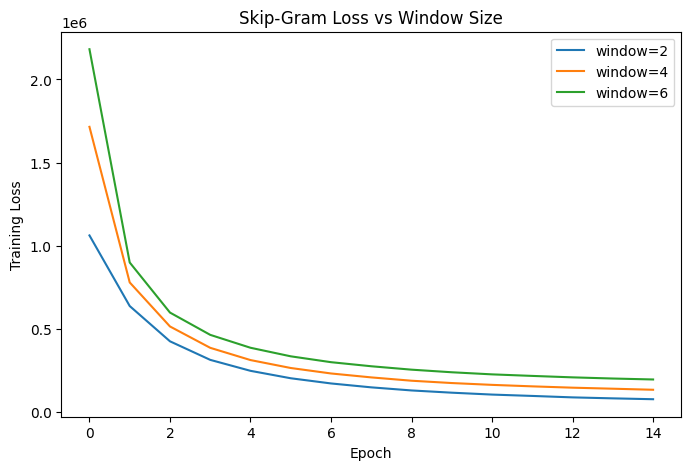

In [149]:
plt.figure(figsize=(8,5))

for w, losses in results_window_sg.items():
    plt.plot(losses, label=f"window={w}")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Skip-Gram Loss vs Window Size")
plt.legend()
plt.show()

In [150]:
test_words = ["btech", "professor"]

for w in window_sizes:
    print(f"\nSkipgram Window size = {w}")

    for word in test_words:
        if word in word_to_idx:
            print(f"\nNearest to '{word}':")
            print(nearest_words(word, embeddings_window_sg[w], word_to_idx, idx_to_word))


Skipgram Window size = 2

Nearest to 'btech':
[('discipline', 0.5997831462258425), ('programme', 0.5507275018022073), ('engineering', 0.528731195201197), ('specialization', 0.5181948869950297), ('student', 0.5051047942449838)]

Nearest to 'professor':
[('seminar', 0.46268919725901575), ('equal', 0.4611460696390806), ('examiners', 0.45660814128647303), ('level', 0.43838688619039856), ('category', 0.4349017542136437)]

Skipgram Window size = 4

Nearest to 'btech':
[('mtech', 0.553546750057446), ('msc', 0.5339567193457664), ('program', 0.5205295316240119), ('department', 0.5126711504472303), ('cse', 0.5092586902276964)]

Nearest to 'professor':
[('recommendation', 0.4848136365848535), ('associate', 0.48236193950052525), ('quantity', 0.47297476298139823), ('running', 0.4618749020531241), ('supervising', 0.45045947769249356)]

Skipgram Window size = 6

Nearest to 'btech':
[('dual', 0.5826699700259551), ('msc', 0.5814870865775148), ('specialization', 0.5250263172858441), ('mtech', 0.5141351

###Effect of embedding dimension Skipgram model

In [151]:
embedding_dims = [50, 100, 200]

results_dim_sg = {}
embeddings_dim_sg = {}

window_size = 2
skip_gram_data = gen_skipgram_data(corpus_indices, window_size)

for dim in embedding_dims:

    print("\nTraining Skipgram with embedding dim =", dim)

    embeddings, losses = train_skipgram_neg(
        skip_gram_data,
        vocab_size,
        embed_dim=dim,
        epochs=30
    )

    results_dim_sg[dim] = losses
    embeddings_dim_sg[dim] = embeddings


Training Skipgram with embedding dim = 50
Epoch 1, Loss: 738727.1145680781
Epoch 2, Loss: 473095.3529633
Epoch 3, Loss: 319652.70222415164
Epoch 4, Loss: 244466.73933896568
Epoch 5, Loss: 199229.1124593086
Epoch 6, Loss: 170109.51011191722
Epoch 7, Loss: 150055.7550433515
Epoch 8, Loss: 135086.36409519362
Epoch 9, Loss: 123143.03277683101
Epoch 10, Loss: 113737.43559148177
Epoch 11, Loss: 105393.29593979362
Epoch 12, Loss: 98866.66172439819
Epoch 13, Loss: 93777.11380162397
Epoch 14, Loss: 88717.69403144089
Epoch 15, Loss: 84843.38940220582
Epoch 16, Loss: 81622.98071573932
Epoch 17, Loss: 78203.32632966705
Epoch 18, Loss: 74747.2391668697
Epoch 19, Loss: 72586.53058464712
Epoch 20, Loss: 70310.31997620848
Epoch 21, Loss: 68278.28406097658
Epoch 22, Loss: 66200.63798519097
Epoch 23, Loss: 64452.03990092583
Epoch 24, Loss: 62877.374257028176
Epoch 25, Loss: 61737.76005389006
Epoch 26, Loss: 60267.32452460789
Epoch 27, Loss: 58502.0308361804
Epoch 28, Loss: 57701.613437170636
Epoch 29, 

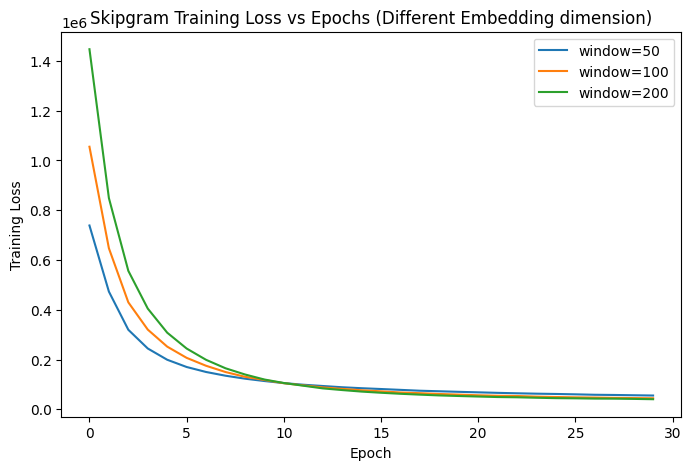

In [152]:
plt.figure(figsize=(8,5))
for w, losses in results_dim_sg.items():
    plt.plot(losses, label=f"window={w}")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Skipgram Training Loss vs Epochs (Different Embedding dimension)")
plt.legend()
plt.show()

In [153]:
test_words = ["btech", "research"]

for dim in embedding_dims:
    print(f"\nSkipgram embedding dim = {dim}")

    for word in test_words:
        if word in word_to_idx:
            print(f"\nNearest to '{word}':")
            print(
                nearest_words(
                    word,
                    embeddings_dim_sg[dim],
                    word_to_idx,
                    idx_to_word
                )
            )


Skipgram embedding dim = 50

Nearest to 'btech':
[('programmes', 0.6347038901289134), ('undergraduate', 0.6338495724838547), ('discipline', 0.6275625787708583), ('compulsory', 0.6215653535728874), ('program', 0.6195545043159881)]

Nearest to 'research':
[('field', 0.6100731945048787), ('requisite', 0.5922175440181835), ('proposal', 0.5802929241753192), ('indiscipline', 0.5782729067014435), ('bachelors', 0.5220411035932881)]

Skipgram embedding dim = 100

Nearest to 'btech':
[('program', 0.5106773591370437), ('msc', 0.47703887577429976), ('duration', 0.47486887036535425), ('admissions', 0.44999700503812545), ('extension', 0.44224236396495725)]

Nearest to 'research':
[('proposal', 0.449889382676894), ('slow', 0.42294157774316815), ('takes', 0.414548096833236), ('qualifier', 0.41418413619406047), ('wide', 0.4115487928026816)]

Skipgram embedding dim = 200

Nearest to 'btech':
[('program', 0.4111273205758273), ('mtech', 0.34750238309057746), ('interview', 0.34043972014614227), ('msc', 0.

####Effect of number of negative samples on skipgram model

In [154]:
neg_sample_values = [2, 5, 10, 15]

results_neg = {}
embeddings_neg = {}   # store embeddings

embedding_dim = 100

for k in neg_sample_values:

    print("\nTraining Skipgram with negative samples =", k)

    embeddings, losses = train_skipgram_neg(
        skipgram_data,
        vocab_size,
        embed_dim=embedding_dim,
        neg_samples=k,
        epochs=20
    )

    results_neg[k] = losses
    embeddings_neg[k] = embeddings


Training Skipgram with negative samples = 2
Epoch 1, Loss: 574782.3349463237
Epoch 2, Loss: 409874.1089395943
Epoch 3, Loss: 329449.0753263507
Epoch 4, Loss: 273971.8863146871
Epoch 5, Loss: 232042.14875970696
Epoch 6, Loss: 197461.89366373818
Epoch 7, Loss: 172763.39898490973
Epoch 8, Loss: 154057.19071368512
Epoch 9, Loss: 140222.09497943826
Epoch 10, Loss: 127239.25951082505
Epoch 11, Loss: 115346.25161265484
Epoch 12, Loss: 106512.97785491474
Epoch 13, Loss: 97409.37965313582
Epoch 14, Loss: 90670.84538073197
Epoch 15, Loss: 84991.31260672284
Epoch 16, Loss: 79063.16167286506
Epoch 17, Loss: 74964.28605157722
Epoch 18, Loss: 70203.22473957748
Epoch 19, Loss: 66582.03231633395
Epoch 20, Loss: 61876.952744620736

Training Skipgram with negative samples = 5
Epoch 1, Loss: 1059139.9606144293
Epoch 2, Loss: 634999.4271825303
Epoch 3, Loss: 422413.47910473234
Epoch 4, Loss: 315632.73704627284
Epoch 5, Loss: 246302.84826702013
Epoch 6, Loss: 203374.76551387343
Epoch 7, Loss: 169421.14243

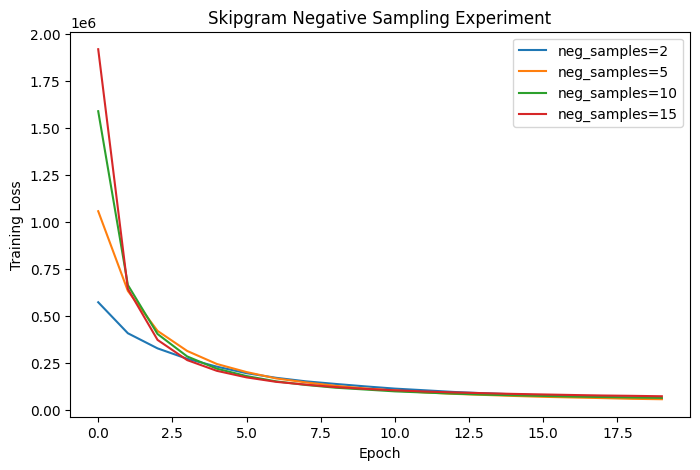

In [155]:
plt.figure(figsize=(8,5))

for k, losses in results_neg.items():
    plt.plot(losses, label=f"neg_samples={k}")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Skipgram Negative Sampling Experiment")
plt.legend()
plt.show()

In [156]:
test_words = ["btech", "research"]

for k in neg_sample_values:
    print(f"\nNegative samples = {k}")

    for word in test_words:
        if word in word_to_idx:
            print(f"\nNearest to '{word}':")
            print(
                nearest_words(
                    word,
                    embeddings_neg[k],
                    word_to_idx,
                    idx_to_word
                )
            )


Negative samples = 2

Nearest to 'btech':
[('programme', 0.5918734803536569), ('assistance', 0.5112255020009591), ('conditions', 0.5005142398935452), ('minimum', 0.4849795717466311), ('program', 0.48186963620195566)]

Nearest to 'research':
[('src', 0.48895766912259153), ('drc', 0.4494803978175839), ('program', 0.44526918695621914), ('two', 0.4104382219565354), ('candidacy', 0.4097591316285433)]

Negative samples = 5

Nearest to 'btech':
[('program', 0.49812669516627744), ('dual', 0.4943616568348377), ('engineering', 0.49125401506092103), ('specialization', 0.4813655324795527), ('mtech', 0.4723325212846523)]

Nearest to 'research':
[('src', 0.514550437887473), ('proposal', 0.5107753766410937), ('fields', 0.45982452216660546), ('upon', 0.45225473915308556), ('composition', 0.44357113230097756)]

Negative samples = 10

Nearest to 'btech':
[('programme', 0.5840945822318674), ('mtech', 0.5051721737472314), ('program', 0.49976216112010013), ('engineering', 0.49177916272508543), ('programs'

In [158]:
embedding_dim = 300
neg_samples = 5

sg_embeddings, loss = train_skipgram_neg(
    skipgram_data, vocab_size, embedding_dim, neg_samples
)

Epoch 1, Loss: 1666145.4445602468
Epoch 2, Loss: 989973.9415201223
Epoch 3, Loss: 650800.2384359216
Epoch 4, Loss: 463466.6901770912
Epoch 5, Loss: 353355.2422664332
Epoch 6, Loss: 272864.5188275874
Epoch 7, Loss: 217141.85394900583
Epoch 8, Loss: 178528.39716074
Epoch 9, Loss: 150118.49907268528
Epoch 10, Loss: 130916.3123797848
Epoch 11, Loss: 112879.8499092458
Epoch 12, Loss: 100232.64146810152
Epoch 13, Loss: 91293.32334814762
Epoch 14, Loss: 84313.80139212715
Epoch 15, Loss: 78099.16826338413
Epoch 16, Loss: 72769.3150671957
Epoch 17, Loss: 68839.43584767019
Epoch 18, Loss: 64644.18000381158
Epoch 19, Loss: 62067.23471118937
Epoch 20, Loss: 60845.642343983985
Epoch 21, Loss: 57636.51958419541
Epoch 22, Loss: 55920.45086481415
Epoch 23, Loss: 54272.33019441072
Epoch 24, Loss: 53564.913791332765
Epoch 25, Loss: 52934.57446382038
Epoch 26, Loss: 51426.717175281214
Epoch 27, Loss: 51312.943343480496
Epoch 28, Loss: 50818.15696747174
Epoch 29, Loss: 49566.35655050409
Epoch 30, Loss: 49

In [160]:
word = "btech"

vec = sg_embeddings[word_to_idx[word]]

print(word, "-", ", ".join(f"{v:.3f}" for v in vec))

btech - 0.830, -0.671, -0.600, -0.036, -0.763, -1.957, -0.970, -0.354, 1.189, 0.538, 0.272, -0.805, -0.180, -0.639, -0.540, 0.512, 0.010, 0.071, -2.230, 0.870, 0.454, -0.504, -0.153, -0.842, -0.662, 0.002, 0.187, 0.123, 0.016, 0.484, -0.152, 0.388, -0.745, -0.222, -0.355, 0.280, -0.589, -0.507, -1.004, -0.910, -1.020, 1.537, -0.746, 0.617, 0.791, 0.466, 0.299, -0.354, 0.611, -0.987, -0.404, 0.805, -0.131, 0.701, 0.745, -0.887, -0.369, -0.180, -0.832, 0.828, -0.147, -2.002, 0.203, -0.615, 1.116, -0.606, 0.222, 0.234, -0.821, 0.239, 0.762, 1.317, -0.241, 0.644, -0.851, -0.627, -0.258, -1.170, 0.448, -0.501, -0.867, -0.210, 0.147, -0.019, 0.512, -0.394, -0.253, 0.337, -0.010, -1.237, -1.178, 0.329, -1.170, -0.416, 0.722, 0.215, -0.407, -0.332, -0.558, -0.967, 1.683, 0.722, 0.333, -0.672, -0.382, -1.723, 0.129, 1.358, -1.375, -0.167, 0.939, -0.642, 0.369, -0.163, 0.421, 1.060, -0.615, -0.799, 0.405, -0.411, -0.107, -0.545, 1.120, 0.814, -0.794, 0.034, -0.016, -1.207, -0.386, -1.570, 0.521,